<a href="https://colab.research.google.com/github/enakirimoto/Machine-Learning-and-Analytics/blob/main/Projeto_Eric_MVP_ML_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Template — MVP: *Machine Learning & Analytics*
**Autor:** Eric Koji Nakirimoto  

**Data:** 27/08/2025

**Matrícula:** 4052025000088

**Dataset:**: [Uber Dataset](https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard/data)



---

# Dataset

## Resumo do Dataset: Análise de Corridas do Uber 2024

Este projeto utiliza o **Uber Ride Analytics Dataset 2024**, um conjunto de dados abrangente que contém informações detalhadas sobre as operações de compartilhamento de viagens do Uber durante o ano de 2024. O dataset oferece ricos insights sobre padrões de reserva, desempenho de veículos, fontes de receita, comportamentos de cancelamento e métricas de satisfação do cliente.

### Visão Geral dos Dados

O conjunto de dados captura um total de **148.770 reservas** em vários tipos de veículos, fornecendo uma visão completa das operações, incluindo corridas bem-sucedidas, cancelamentos e métricas financeiras.

**Estatísticas Principais fornecidas pelo dataset:**
* **Total de Reservas:** 148,77 mil
* **Taxa de Sucesso:** 65,96% (93 mil corridas concluídas)
* **Taxa de Cancelamento Total:** 25% (37,43 mil reservas canceladas)
    * **Cancelamentos por Clientes:** 19,15% (27 mil corridas)
    * **Cancelamentos por Motoristas:** 7,45% (10,5 mil corridas)

---

### Objetivo do Projeto de Machine Learning

O principal objetivo deste trabalho é utilizar os dados, com foco especial nos **cancelamentos por parte dos motoristas**, para desenvolver um **modelo preditivo**. A meta é criar um sistema que consiga identificar, com base nos padrões históricos e dados em tempo real, a alta probabilidade de um motorista cancelar uma corrida *antes* que ela seja aceita. O desenvolvedor desse modelo já passou raiva diversas vezes por conta do excesso de cancelamentos e quer identificar se é possível prever isso e sugerir ao Uber que utilize esse modelo pois esse tipo de cancelamento é desagradável.

Na prática, ao prever um cancelamento iminente, a plataforma poderia **evitar o envio da solicitação de viagem** para esse motorista específico. Isso otimizaria a alocação de corridas para motoristas com maior probabilidade de aceitar e completar a viagem, resultando na redução do tempo de espera do cliente e na melhoria da eficiência geral do serviço.

---

### Atributos

O dataset possui os seguintes atributos.


| Nome da Coluna | Descrição |
| :--- | :--- |
| **Date** | Data da reserva |
| **Time** | Hora da reserva |
| **Booking ID** | Identificador único para cada reserva de corrida |
| **Booking Status** | Status da reserva (Concluída, Cancelada pelo Cliente, Cancelada pelo Motorista, etc.) |
| **Customer ID** | Identificador único para clientes |
| **Vehicle Type** | Tipo de veículo (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan) |
| **Pickup Location** | Local de partida da corrida |
| **Drop Location** | Local de destino da corrida |
| **Avg VTAT** | Tempo médio para o motorista chegar ao local de partida (em minutos) |
| **Avg CTAT** | Duração média da viagem da partida ao destino (em minutos) |
| **Cancelled Rides by Customer** | Indicador de cancelamento iniciado pelo cliente |
| **Reason for cancelling by Customer**| Motivo do cancelamento pelo cliente |
| **Cancelled Rides by Driver** | Indicador de cancelamento iniciado pelo motorista |
| **Driver Cancellation Reason** | Motivo do cancelamento pelo motorista |
| **Incomplete Rides** | Indicador de corrida incompleta |
| **Incomplete Rides Reason** | Motivo para corridas incompletas |
| **Booking Value** | Valor total da tarifa da corrida |
| **Ride Distance** | Distância percorrida durante a corrida (em km) |
| **Driver Ratings** | Avaliação dada ao motorista (escala de 1 a 5) |
| **Customer Rating** | Avaliação dada pelo cliente (escala de 1 a 5) |
| **Payment Method** | Método utilizado para pagamento (UPI, Dinheiro, Cartão de Crédito, Carteira Uber, Cartão de Débito) |


#Início da importação de bibliotecas utilizadas


In [34]:
import os, random, time, sys, math
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score)

from sklearn.model_selection import StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform

# Importando o dataset

In [35]:


url = "https://raw.githubusercontent.com/enakirimoto/Machine-Learning-and-Analytics/refs/heads/main/ncr_ride_bookings.csv"

df = pd.read_csv(url)

# Check de dados
print(df.head())

         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides by Driver  \
0  ...         

#Análise exploratória

## Hipóteses na análise
* Na análise exploratória conseguimos identificar os melhores atributos para o treinamento do modelo;
* Na análise dos dados conseguiremos identificar ser há alguma anomalia e se for necessário tratar os dados.

## Hipóteses do modelo
* Com o treinamento dos modelos espera-se avaliar qual a acurácia de implantação de diversas técnicas para definir o melhor método para utilização.

In [36]:
#Análises genéricas do dataset

print(df.describe)
print(df.info())
print(df.columns)

<bound method NDFrame.describe of               Date      Time    Booking ID   Booking Status   Customer ID  \
0       2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1       2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2       2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3       2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4       2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   
...            ...       ...           ...              ...           ...   
149995  2024-11-11  19:34:01  "CNR6500631"        Completed  "CID4337371"   
149996  2024-11-24  15:55:09  "CNR2468611"        Completed  "CID2325623"   
149997  2024-09-18  10:55:15  "CNR6358306"        Completed  "CID9925486"   
149998  2024-10-05  07:53:34  "CNR3030099"        Completed  "CID9415487"   
149999  2024-03-10  15:38:03  "CNR3447390"        Completed  "CID4108667"   

         Vehicle Type         Pickup Loca

#Pré análise
O dataset possui 150k linhas e 21 colunas. Entendendo que o objetivo é prever os cancelamentos feitos pelo motorista, entende-se que se faz necessário entender quais são os atributos que possuem valores que podem ser utilizados para análise exploratória.

In [37]:
#Filtrando os dados de corridas canceladas
df_filtrado = df[df['Cancelled Rides by Driver'].notna()]
print(df_filtrado)

#Entendendo a quantidade de variáveis que cada atributo tem
print(df_filtrado.nunique())

              Date      Time    Booking ID       Booking Status   Customer ID  \
12      2024-06-25  22:44:15  "CNR4386945"  Cancelled by Driver  "CID5543520"   
17      2024-12-15  15:08:25  "CNR6739317"  Cancelled by Driver  "CID8682675"   
19      2024-05-24  19:53:57  "CNR9465840"  Cancelled by Driver  "CID9046501"   
26      2024-01-26  09:44:00  "CNR3614535"  Cancelled by Driver  "CID2507102"   
30      2024-05-18  17:37:52  "CNR2178654"  Cancelled by Driver  "CID3631860"   
...            ...       ...           ...                  ...           ...   
149959  2024-01-24  13:37:23  "CNR4666409"  Cancelled by Driver  "CID7135403"   
149973  2024-02-06  18:03:44  "CNR4828704"  Cancelled by Driver  "CID3769079"   
149977  2024-03-02  13:22:23  "CNR9330412"  Cancelled by Driver  "CID3815156"   
149979  2024-10-05  17:30:25  "CNR8459494"  Cancelled by Driver  "CID9568404"   
149990  2024-09-26  12:31:22  "CNR3212810"  Cancelled by Driver  "CID6199171"   

       Vehicle Type     Pic

#Diagnóstico

Entendo que os atributos mais interessantes para explorar pensando-se em treinar um modelo são:

- Date: Entender se há algum dia em potêncial que gera esse cancelamento
- Time: Entender se há algum horário que costuma gerar esse cancelamento
- Tipo de veículo: Há poucos tipos de veículos e quero entender se há algum tipo de veículo que gera mais cancelamentos
- Avg VTAT: Entender se o tempo para chegar ao trajeto influência

Ainda há outras opções como o "Pickup Location" e "Drop Location". Por possuirem 176 variáveis acredito que serão muitas variáveis mas vou avaliar as variáveis que mais se repetem para identificar se há algum padrão.

Pickup Location
Nehru Place         190
Shivaji Park        185
GTB Nagar           183
Saket               179
Pragati Maidan      179
Vinobapuri          176
Punjabi Bagh        176
Rajouri Garden      176
AIIMS               176
Nawada              174
Chhatarpur          173
Rohini East         173
Kadarpur            172
Qutub Minar         172
Patel Chowk         171
Munirka             171
Dwarka Sector 21    170
Karkarduma          170
Akshardham          170
Barakhamba Road     170
Name: count, dtype: int64
Drop Location
Basai Dhankot          192
Vasant Kunj            183
Ardee City             178
Udyog Vihar            178
Govindpuri             178
Hauz Khas              177
Gurgaon Sector 29      176
Bhikaji Cama Place     176
Ghitorni               176
Vidhan Sabha           175
Shastri Nagar          175
Pataudi Chowk          174
Gurgaon Sector 56      173
Keshav Puram           172
Moolchand              172
GTB Nagar              172
Nehru Place            171
RK Pu

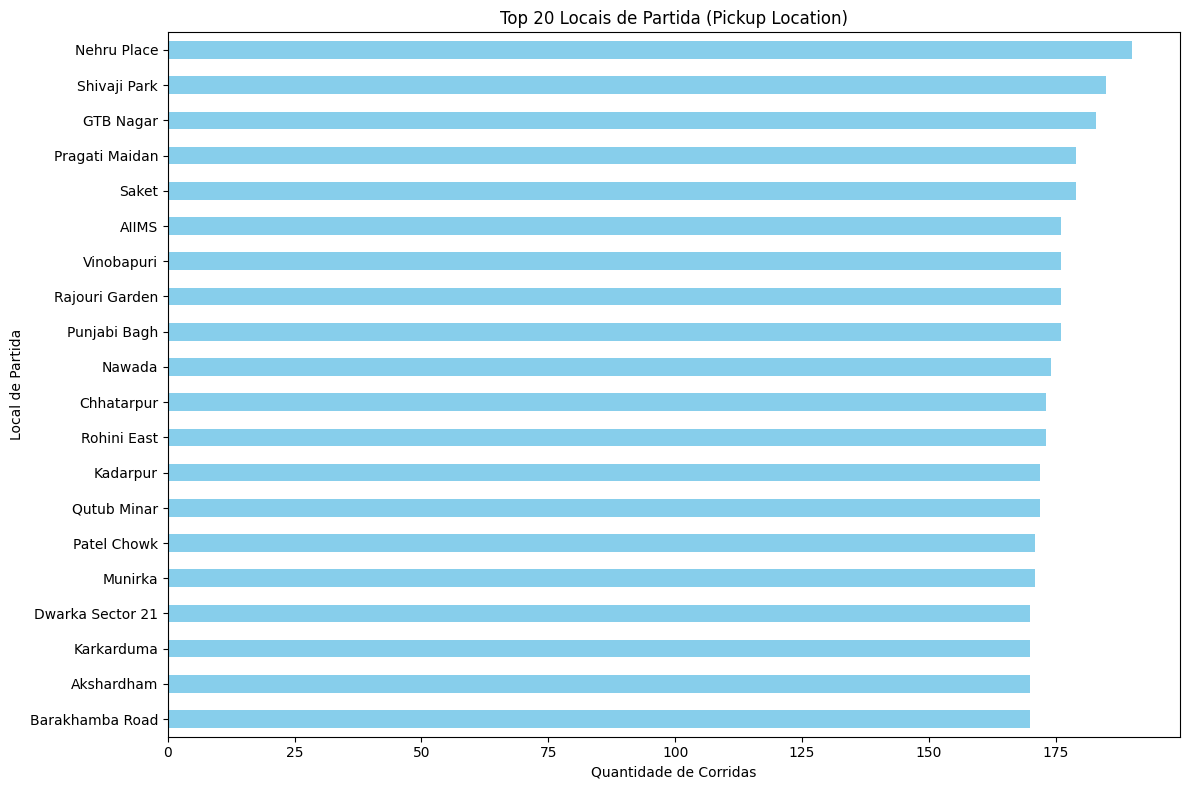

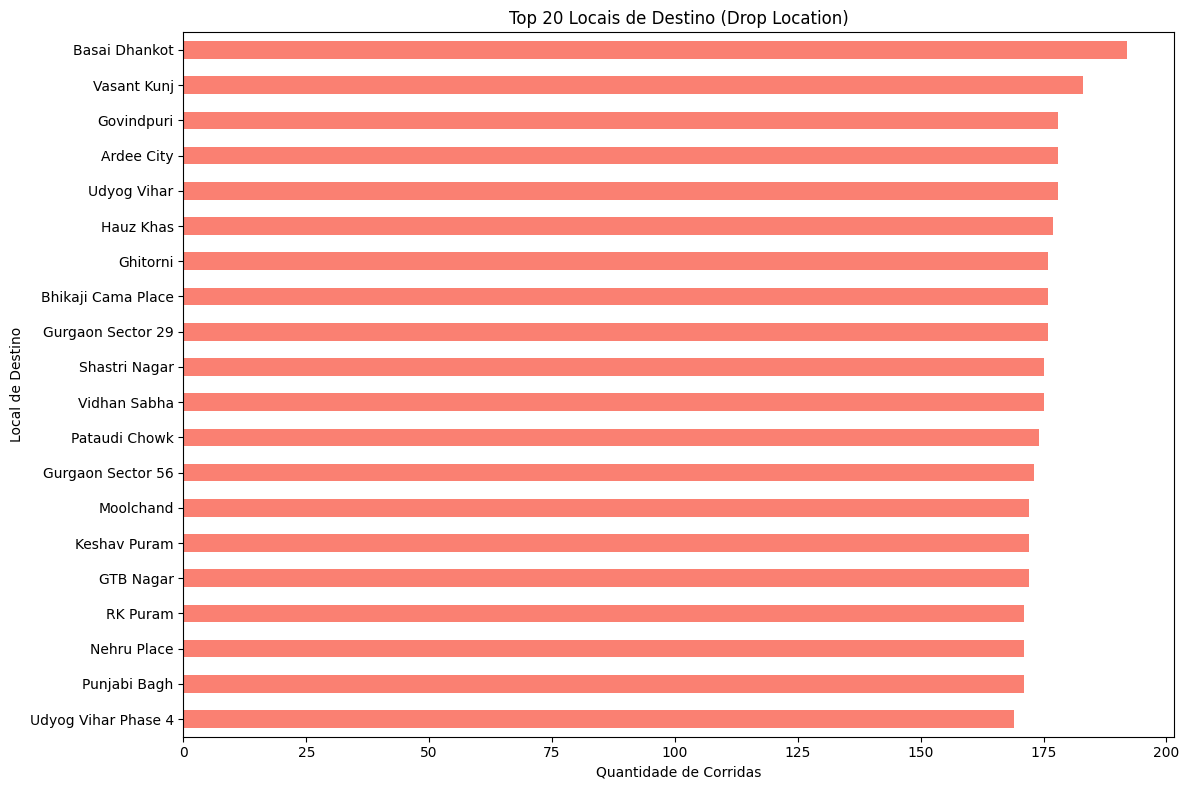

In [38]:
#Separando as top 20 maiores distribuições para entender se consigo dfazer algum agrupamento
top_20_pickup = df_filtrado['Pickup Location'].value_counts().nlargest(20)
print(top_20_pickup)


plt.figure(figsize=(12, 8))
top_20_pickup.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Top 20 Locais de Partida (Pickup Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Partida')
plt.tight_layout()

top_20_drop = df_filtrado['Drop Location'].value_counts().nlargest(20)
print(top_20_drop)
plt.figure(figsize=(12, 8))
top_20_drop.sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title('Top 20 Locais de Destino (Drop Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Destino')
plt.tight_layout()

Pickup Location
Seelampur              124
Ghitorni Village       125
Sadar Bazar Gurgaon    128
IMT Manesar            129
Kanhaiya Nagar         130
Old Gurgaon            131
Yamuna Bank            131
Hauz Khas              132
Jama Masjid            132
Peeragarhi             132
Welcome                132
Okhla                  133
Laxmi Nagar            133
Noida Sector 18        134
Arjangarh              135
Tis Hazari             136
Mandi House            136
Meerut                 136
Gurgaon Sector 29      136
Delhi Gate             136
Name: count, dtype: int64
Drop Location
Badarpur            125
Adarsh Nagar        125
Saket               127
Noida Extension     129
Aya Nagar           130
Pulbangash          130
Panchsheel Park     131
Preet Vihar         132
Okhla               133
Ghitorni Village    134
IFFCO Chowk         134
Pitampura           134
Tagore Garden       136
Lal Quila           137
Inderlok            137
Ramesh Nagar        137
India Gate          

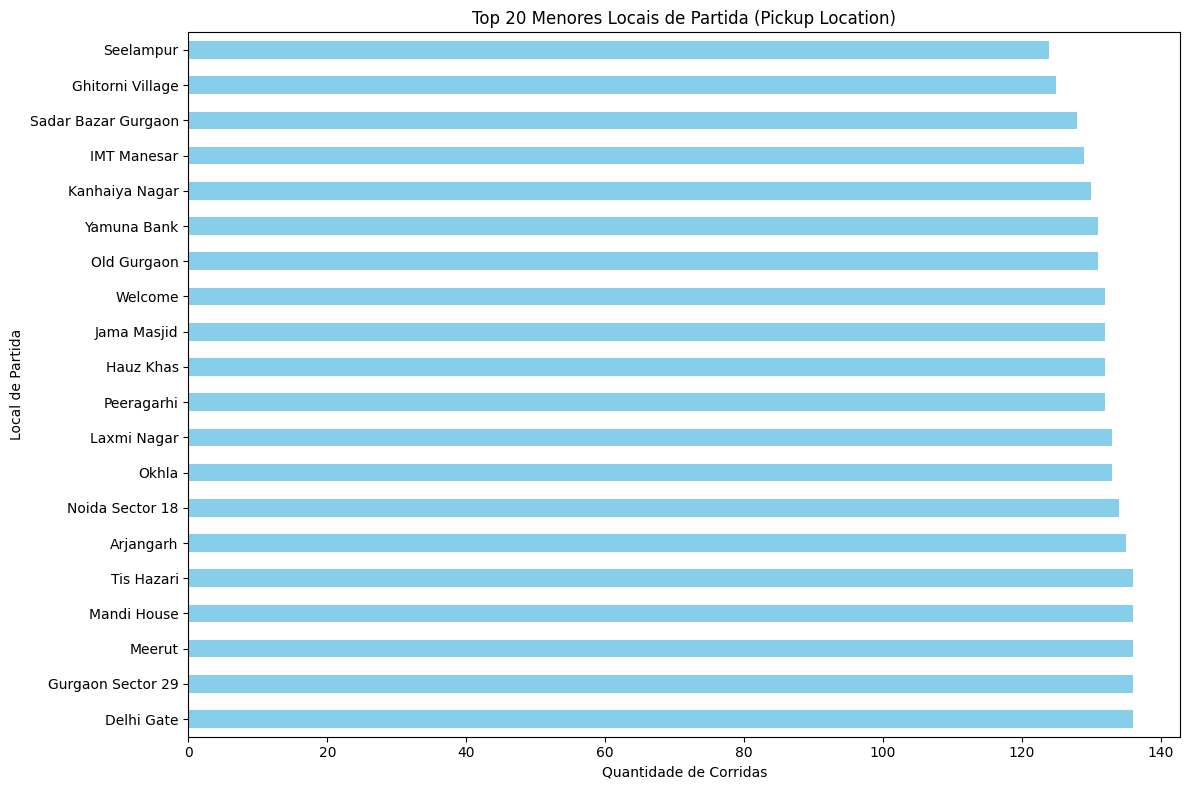

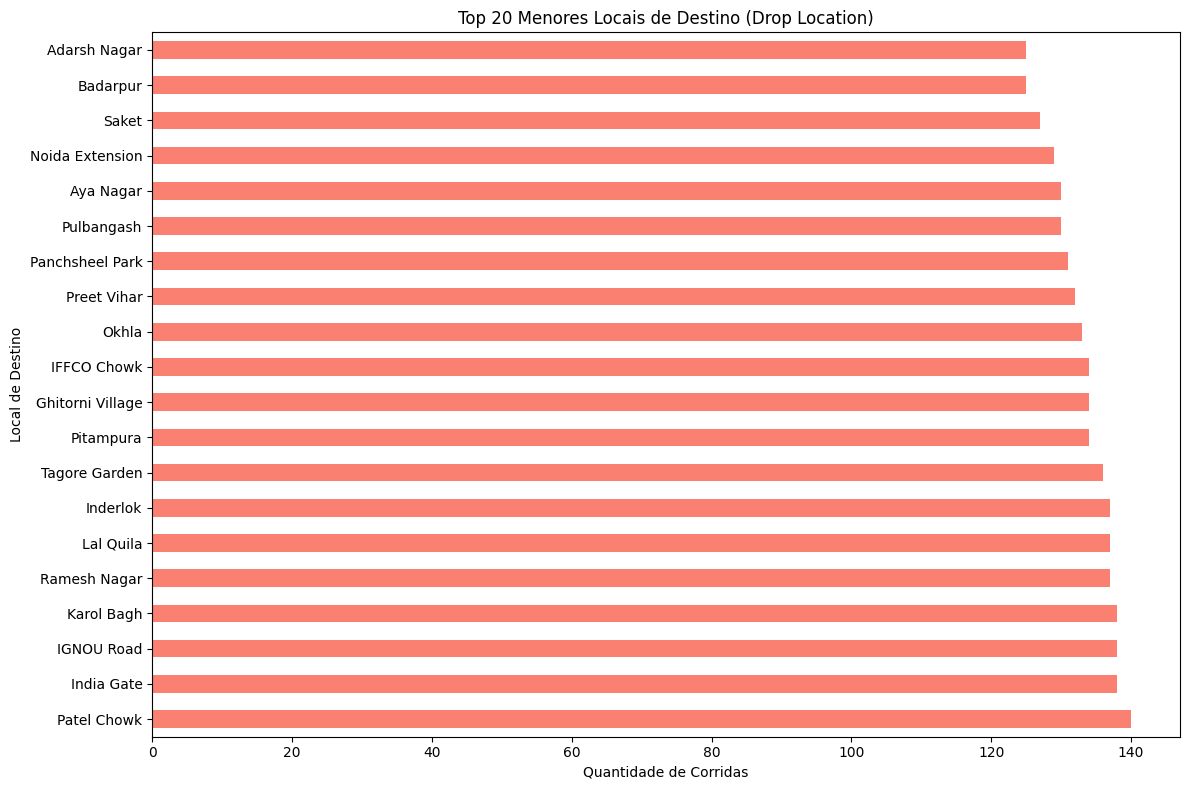

In [39]:
#Separando as top 20 maiores distribuições para entender se consigo dfazer algum agrupamento
top2_20_pickup = df_filtrado['Pickup Location'].value_counts().nsmallest(20)
print(top2_20_pickup)


plt.figure(figsize=(12, 8))
top2_20_pickup.sort_values(ascending=False).plot(kind='barh', color='skyblue')
plt.title('Top 20 Menores Locais de Partida (Pickup Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Partida')
plt.tight_layout()

top2_20_drop = df_filtrado['Drop Location'].value_counts().nsmallest(20)
print(top2_20_drop)
plt.figure(figsize=(12, 8))
top2_20_drop.sort_values(ascending=False).plot(kind='barh', color='salmon')
plt.title('Top 20 Menores Locais de Destino (Drop Location)')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Local de Destino')
plt.tight_layout()


print(df_filtrado['Driver Cancellation Reason'].value_counts())

# Diagnóstico dos dados
Analisando-se os dados das origens e destinos não foi possível identificar um local que concentre a maior distribuição de origens ou destino. Se ao menos um grupo de locais apresentace um valor significativo e discrepante de cancelamentos seria possível agrupar para criar um novo atributo para esses locais. Para finalizar a análise sobre esses locais é preciso entender se esse número de cancelamentos é representativo se analisado percentualmente em relação a todos os chamados que são feitos. Parte-se da hipotese que embora os valores de cancelamento não apresentem alguma característica que destaque na análise visual algum destino, estes podem ter um destaque se comparados com o total de corridas que são solicitadas para aquele destino ou para aquele local de partida.

Também identificou-se os motivos de cancelamento.

| Motivo do Cancelamento | Quantidade |
| :--- | :--- |
| Customer related issue | 6837 |
| The customer was coughing/sick | 6751 |
| Personal & Car related issues | 6726 |
| More than permitted people in there | 6686 |

Em uma análise sobre os motivos, entende-se que o motivo de tosse/gripe é algo que depende do bom senso do cliente, acredita-se que não dá para prever esse bom senso sem ter um vínculo com o usuário e poderia ser resolvido com um aviso. Por conseguinte, na construção do modelo esses motivos serão eliminados da base de dados.

Sobre os problemas pessoais, embora o entendimento do analista seja de que possam ser causas aleatórias, os dados serão mantidos pois a aleatóriedade desses eventos podem ser relacionados com meses do ano ou horários em um dia.



Cancelled Rides by Driver
0.0    123000
1.0     27000
Name: count, dtype: int64
                 total_rides  driver_cancellations
Pickup Location                                   
AIIMS                    918                 176.0
Adarsh Nagar             858                 141.0
Akshardham               839                 170.0
Ambience Mall            873                 151.0
Anand Vihar              859                 142.0
...                      ...                   ...
Vidhan Sabha             825                 154.0
Vinobapuri               823                 176.0
Vishwavidyalaya          895                 169.0
Welcome                  836                 132.0
Yamuna Bank              824                 131.0

[176 rows x 2 columns]
cancellation_rate_percent
18.666667    2
16.433566    1
19.172113    1
17.296678    1
16.530850    1
16.847172    1
20.262217    1
16.666667    1
17.081448    1
17.964824    1
18.421053    1
18.505747    1
19.598583    1
17.263844   

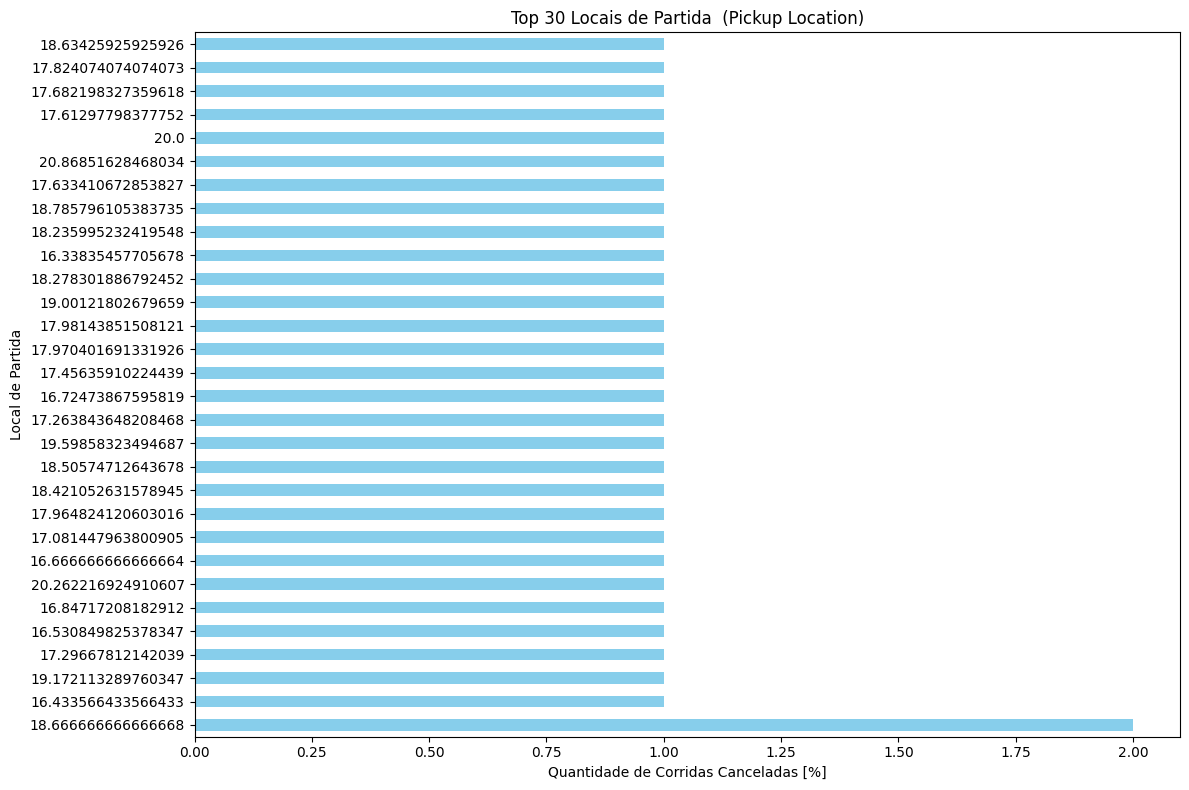

In [54]:
#Criando outros dataframes para não afetar o original
df_calc = df.copy()
df_calc = df_calc.fillna(0)
print(df_calc['Cancelled Rides by Driver'].value_counts())

location_stats = df_calc.groupby('Pickup Location').agg(
    total_rides=('Booking ID', 'count'),
    driver_cancellations=('Cancelled Rides by Driver', 'sum')
)
print(location_stats)
significant_locations = location_stats.copy()
significant_locations['cancellation_rate_percent'] =  (significant_locations['driver_cancellations'] / significant_locations['total_rides']) * 100
#print(significant_locations)


topsignigicant_30_pickup = significant_locations['cancellation_rate_percent'].value_counts().nlargest(30)
print(topsignigicant_30_pickup)

plt.figure(figsize=(12, 8))
topsignigicant_30_pickup.sort_values(ascending=False).plot(kind='barh', color='skyblue')
plt.title('Top 30 Locais de Partida  (Pickup Location)')
plt.xlabel('Quantidade de Corridas Canceladas [%]')
plt.ylabel('Local de Partida')
plt.tight_layout()


top_20_highest_rate = significant_locations.nlargest(20, 'cancellation_rate_percent')

final_result = top_20_highest_rate.sort_values('cancellation_rate_percent', ascending=False)

final_result['cancellation_rate_percent'] = final_result['cancellation_rate_percent'].map('{:.2f}%'.format)

print("As 20 'Pickup Locations' com maior taxa de cancelamento por motorista (em ordem crescente):")
print(final_result.to_markdown(index=True))

In [41]:
# dx = df.groupby("Cancelled Rides by Driver").
# print(dx)

SyntaxError: invalid syntax (ipython-input-3608374251.py, line 1)


## ✅ Checklist do MVP (o que precisa conter)
- [ ] **Problema definido** e contexto de negócio
- [ ] **Carga e preparação** dos dados (sem vazamento de dados)
- [ ] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [ ] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [ ] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [ ] **Otimização de hiperparâmetros**
- [ ] **Avaliação** com **métricas adequadas** e discussão de limitações
- [ ] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [ ] **Pipelines reprodutíveis** (sempre que possível)



## 1. Escopo, objetivo e definição do problema
**TODO:** Explique brevemente:
- Contexto do problema e objetivo (ex.: previsão de churn, detecção de fraude, previsão de demanda, segmentação de clientes etc.).  
- Tipo de tarefa: **classificação**, **regressão**, **clusterização** ou **séries temporais (forecasting)**.  
- Área de aplicação: visão computacional, NLP, dados tabulares, sensores, etc.  
- Valor para o negócio/usuário.



## 2. Reprodutibilidade e ambiente
Especifique o ambiente. Por exemplo:
- Bibliotecas usadas.
- Seeds fixas para reprodutibilidade.

In [ ]:
# === Setup básico e reprodutibilidade ===
import os, random, time, sys, math
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score)

from sklearn.model_selection import StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Para frameworks que suportam seed adicional (ex.: PyTorch/TensorFlow), documente aqui:
# import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
# import tensorflow as tf; tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)


### 2.1 Dependências (opcional)
Instale pacotes extras se necessário. **Mantenha o projeto enxuto** para facilitar a correção.


In [ ]:

# Exemplo: descomente o que precisar
# !pip install -q scikit-learn imbalanced-learn xgboost lightgbm catboost optuna
# !pip install -q pandas-profiling ydata-profiling
# !pip install -q matplotlib seaborn plotly
# !pip install -q statsmodels pmdarima


### 2.2 Funções python (opcional)
Defina, se necessário, funções em Python para reutilizar seu código e torná-lo mais organizado. Essa é uma boa prática de programação que facilita a leitura, manutenção e evolução do seu projeto.

In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")
    auc = roc_auc_score(y_true, proba[:,1]) if (proba is not None and proba.shape[1]==2) else np.nan
    return {"accuracy": acc, "f1_weighted": f1w, "roc_auc": auc}

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

def evaluate_clustering(X_original, model):
    # Silhouette requer >1 cluster e dados transformados
    try:
        if hasattr(model.named_steps["pre"], "transform"):
            X_emb = model.named_steps["pre"].fit_transform(X_original)  # cuidado: apenas para demo
        else:
            X_emb = X_original
        labels = model.named_steps["model"].fit_predict(X_emb)
        sil = silhouette_score(X_emb, labels)
        return {"silhouette": sil}
    except Exception as e:
        return {"silhouette": np.nan, "erro": str(e)}


## 3. Dados: carga, entendimento e qualidade
**TODO:** descreva a origem dos dados, dicionário de variáveis e licença/ética quando aplicável.  
Evite **vazamento de dados**. Se usar feature store ou dados sintéticos, explique.


In [ ]:

# === Carga dos dados ===

# Exemplo:
# df = pd.read_csv('dados.csv')

# Placeholder para não quebrar o template:
df = pd.DataFrame({
    "feature_num_1": np.random.normal(size=500),
    "feature_num_2": np.random.uniform(0, 10, size=500),
    "feature_cat_1": np.random.choice(["A","B","C"], size=500),
    "target_reg": np.random.normal(loc=50, scale=10, size=500),
    "target_clf": np.random.choice([0,1], size=500, p=[0.6,0.4]),
    "timestamp": pd.date_range('2024-01-01', periods=500, freq='D')
})
df.head()


In [ ]:

# === Verificações iniciais ===
display(df.sample(5))
print("\nFormato:", df.shape)
print("\nTipos:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())



### 3.1 Análise exploratória resumida (EDA)
**TODO:** inclua gráficos e tabelas essenciais para entender o problema e levantar hipóteses.  
Evite EDA muito extensa — foque no que afeta as decisões de modelagem.


In [ ]:
# Histograma numérico (exemplo)
_ = df["feature_num_1"].hist(bins=30)
plt.title("Distribuição - feature_num_1")
plt.show()

# Contagem categórica (exemplo)
_ = df["feature_cat_1"].value_counts().plot(kind="bar")
plt.title("Contagem - feature_cat_1")
plt.show()



## 4. Definição do target, variáveis e divisão dos dados
**TODO:** escolha o **target** (ou defina a tarefa de clusterização/forecast).  
- Em **séries temporais**, **não embaralhe** e use divisões temporais (ex.: `TimeSeriesSplit`).
- Em **classificação desequilibrada**, considere **estratégias para desbalanceamento** (ex.: `class_weight`, undersampling/oversampling).

> **Atenção:** Todas as **transformações** aprendidas devem ser **ajustadas no treino** e **aplicadas no validação/teste**. Recomendamos usar **pipelines**.


In [ ]:
# Selecione o tipo de problema: 'classificacao' | 'regressao' | 'clusterizacao' | 'serie_temporal'
PROBLEM_TYPE = "classificacao"  # TODO: ajuste

# Defina features e target conforme o problema
if PROBLEM_TYPE == "classificacao":
    target = "target_clf"
    features = [c for c in df.columns if c not in [target, "timestamp"]]
elif PROBLEM_TYPE == "regressao":
    target = "target_reg"
    features = [c for c in df.columns if c not in [target, "timestamp"]]
elif PROBLEM_TYPE == "clusterizacao":
    target = None
    features = [c for c in df.columns if c not in ["target_clf","target_reg","timestamp"]]
elif PROBLEM_TYPE == "serie_temporal":
    target = "target_reg"  # Exemplo
    features = [c for c in df.columns if c not in [target]]
else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("PROBLEM_TYPE:", PROBLEM_TYPE)
print("Target:", target)
print("N features:", len(features))

# Divisão dos dados
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[target].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y if PROBLEM_TYPE=="classificacao" else None
    )
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    # Sem target — você pode reservar um hold-out para avaliação externa se fizer sentido de negócio.
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "serie_temporal":
    # Ordenar por tempo e criar cortes temporais (exemplo simples hold-out temporal)
    df_sorted = df.sort_values("timestamp")
    cutoff = int(len(df_sorted)*0.8)
    train, test = df_sorted.iloc[:cutoff], df_sorted.iloc[cutoff:]
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test   = test.drop(columns=[target]),  test[target]
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)


## 5. Tratamento de dados e **Pipeline** de pré-processamento
Crie um **Pipeline** com as etapas necessárias (limpeza, imputação, encoding, escala, seleção de atributos, etc.)  
Isso garante **reprodutibilidade** e evita **vazamento**.


In [ ]:
num_cols = [c for c in X_train.columns if str(X_train[c].dtype).startswith(("float","int"))]
cat_cols = [c for c in X_train.columns if c not in num_cols and c != "timestamp"]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

print("num_cols:", num_cols[:5], "...")
print("cat_cols:", cat_cols[:5], "...")


## 6. Baseline e modelos candidatos
Se possivek, comece com uma **baseline simples** (ex.: DummyClassifier/Regressor) e evolua para modelos mais fortes. O baseline pode ser seu primeiro modelo!  

**Compare** ao menos **duas abordagens**.

> Para **deep learning** (visão computacional/NLP/séries), crie uma seção específica (p. ex., `TensorFlow`/`PyTorch`) e documente arquitetura, parâmetros e tempo de treino.


In [ ]:
# === Baselines ===
if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))])
    candidates = {
        "LogisticRegression": Pipeline([("pre", preprocess), ("model", LogisticRegression(max_iter=200, random_state=SEED))]),
        "RandomForest": Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))])
    }
elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyRegressor(strategy="median"))])
    candidates = {
        "Ridge": Pipeline([("pre", preprocess), ("model", Ridge(random_state=SEED))]),
        "RandomForestReg": Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    }
elif PROBLEM_TYPE == "clusterizacao":
    # baseline não se aplica diretamente; use um método simples (ex.: KMeans com k fixo) como referência.
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", KMeans(n_clusters=3, random_state=SEED))])
    candidates = {
        "KMeans_k3": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=3, random_state=SEED))]),
        "KMeans_k5": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=5, random_state=SEED))])
    }
elif PROBLEM_TYPE == "serie_temporal":
    # Em séries temporais, a baseline pode ser "naive" (último valor) — aqui, apenas um placeholder.
    # Para modelos clássicos, pode considerar por exemplo Regressores com janelas (feature engineering temporal).
    baseline = None
    candidates = {}
else:
    raise ValueError("PROBLEM_TYPE inválido.")

baseline



### 6.1 Treino e avaliação rápida (baseline vs candidatos)
Use **métricas adequadas** ao tipo de problema. Documente suas observações.


In [ ]:
results = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    t1 = time.time()
    if PROBLEM_TYPE == "classificacao":
        y_pred = baseline.predict(X_test)
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        y_pred = baseline.predict(X_test)
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(t1 - t0, 3)

    # Candidatos
    for name, pipe in candidates.items():
        t0 = time.time()
        pipe.fit(X_train, y_train)
        t1 = time.time()
        if PROBLEM_TYPE == "classificacao":
            y_pred = pipe.predict(X_test)
            proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            y_pred = pipe.predict(X_test)
            results[name] = evaluate_regression(y_test, y_pred)
        results[name]["train_time_s"] = round(t1 - t0, 3)

elif PROBLEM_TYPE == "clusterizacao":
    # Baseline e candidatos (ex.: silhouette)
    # Observação: em um projeto real, evite refit em dados de teste fora de validação apropriada.
    results["baseline"] = evaluate_clustering(X_test, baseline)
    for name, pipe in candidates.items():
        results[name] = evaluate_clustering(X_test, pipe)

elif PROBLEM_TYPE == "serie_temporal":
    # TODO: implemente métricas específicas (ex.: MAE/MAPE/RMSE out-of-time)
    results["baseline_naive"] = {"MAE": None, "MAPE": None, "RMSE": None, "obs": "Implementar baseline temporal."}

pd.DataFrame(results).T



## 7. Validação e Otimização de Hiperparâmetros
Use **validação cruzada** apropriada ao problema (Ex: **`StratifiedKFold`** para classificação; **`KFold`** para regressão).  
Faça **tuning** com `GridSearchCV`/`RandomizedSearchCV`.


In [ ]:
if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model = Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scorer = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model = Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scorer = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "clusterizacao":
    # Clusterização: tuning diferente (ex.: número de clusters). Métricas internas (silhouette) ou externas (se houver rótulos).
    cv = None
    model = Pipeline([("pre", preprocess), ("model", KMeans(random_state=SEED))])
    param_dist = {"model__n_clusters": randint(2, 10)}
    scorer = None

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    # Ex.: usar um regressor com janelas/defasagens previamente criadas
    model = Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 300),
        "model__max_depth": randint(3, 15)
    }
    scorer = "neg_mean_absolute_error"

# Executar busca aleatória (exemplo geral — ajuste para seu caso)
if PROBLEM_TYPE != "clusterizacao":
    search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, cv=cv, scoring=scorer, random_state=SEED, n_jobs=-1, verbose=1)
    search.fit(X_train, y_train)
    print("Melhor score (CV):", search.best_score_)
    print("Melhores parâmetros:", search.best_params_)
else:
    print("Para clusterização, avalie k em um range e compare silhouette/indíces de validade. Ex.: varra k de 2 a 10.")



## 8. Avaliação final, análise de erros e limitações
- **Compare** baseline vs melhor modelo.  
- Faça **análise de erros** (ex.: matriz de confusão, casos pior previstos, resíduos).  
- Discuta **limitações**: dados, métricas, viés, generalização.


In [ ]:
# Exemplo de re-treino no conjunto de treino+validação (se aplicável) e avaliação no teste

if PROBLEM_TYPE in ["classificacao", "regressao"] and 'search' in globals() and hasattr(search, "best_estimator_"):
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        from sklearn.metrics import classification_report, ConfusionMatrixDisplay
        print(classification_report(y_test, y_pred))
        try:
            ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
            plt.title("Matriz de confusão - Melhor modelo")
            plt.show()
        except Exception as e:
            print("Não foi possível plotar a matriz de confusão:", e)
    else:
        print('Metricas para avaliar a regressão: ', evaluate_regression(y_test, y_pred))
elif PROBLEM_TYPE == "clusterizacao":
    print("Realize análise qualitativa/negócio dos clusters. Visualize centros e perfis.")
elif PROBLEM_TYPE == "serie_temporal":
    print("Avalie métricas fora do tempo; plote série real vs prevista.")


## 9. Engenharia de atributos (detalhe)
**TODO:** Documente as escolhas: seleção/extração, encoding, criação de variáveis temporais (lags, médias móveis), TF-IDF/embeddings (NLP), augmentations (visão), etc.



## 10. (Opcional) Deep Learning / Fine-tuning
Se usar DL, descreva: arquitetura, hiperparâmetros, _early stopping_, tamanho do batch, épocas, e se houve **fine-tuning** de modelos pré-treinados.



## 11. Boas práticas e rastreabilidade
- **Baseline** claro e justificativas para melhorias.  
- **Pipelines** (evitar vazamento).  
- **Decisões de projeto** documentadas (o que tentou e por quê).



## 12. Conclusões e próximos passos
**TODO:** Resuma resultados, trade-offs, e proponha melhorias futuras (mais dados, features, modelos, tuning).



## 13. Salvando artefatos (modelos e pipeline)
Se o treinamento dos modelos demora mais de 3 minutos, recomendamos salvar o **modelo/pipeline** após o treinamento e depois apenas carregar o arquivo (ex: .pkl, .h5) salvo em outra célula, sem precisar treinar novamente.  